# QKD IR Benchmark — Local Linux Runtime (Sequential N sweep)

Runs the Phase 1 benchmark locally for several frame lengths in series,
showing full results (plots + summary) for each `N` *before* moving on
to the next.

- the repo is already cloned at the notebook's location,
- the project is installed (`pip install -e .` or its deps are present),
- outputs go to `./local_results/N{N}/` (one subdir per frame length).

**Workflow:**
1. Cell 1: env sanity check.
2. Cell 2: sweep parameters (`N_VALUES`, common knobs).
3. Cell 3: main loop — for each `N`, generate code pool if missing, run
   QBER + mismatch sweeps, save artefacts, render plots and summary inline.
4. Cell 4: cross-`N` comparison plot + global zip.

> **Setup note — code-pool quality.** The LDPC code pool used here
> (`src/codes/elkouss.py`) is built with a single generic degree
> polynomial across all rates rather than the per-rate Elkouss 2009
> Table I coefficients used by Mueller 2025 and Borisov 2023. Codes at
> R ≥ 0.85 underperform their paper counterparts at the lowest QBERs.
> To stay in the regime where the placeholder pool decodes reliably,
> the QBER sweep starts at 2% (instead of 0.5%) and Borisov's `f_start`
> is set to 1.45 (paper value 1.15) so the rate selector stays at the
> rates the pool can decode. Full reproduction of the paper numbers at
> Q < 2% would require regenerating the pool with the real Elkouss
> polynomials — left as future work.

## Cell 1 — Environment sanity check

Confirms deps are importable and pins the repo dir as the working
directory. If `sequence` is missing, install it with
`pip install -e .` from the repo root (or `pip install sequence`).

In [5]:
!pip install -r requirements.txt

  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached sequence-0.8.5-py3-none-any.whl.metadata (9.5 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached dash-4.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached dash_bootstrap_components-2.0.4-py3-none-any.whl.metadata (18 kB)
  Using cached dash_core_components-2.0.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached dash_cytoscape-1.0.2-py3-none-any.whl
  Using cached dash_html_components-2.0.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached dash_table-5.0.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached gmpy2-2.3.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.5 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached pandas_stubs-2.3.3.260113-py3-none-any.whl.metadata (10 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached pyte

In [9]:
import os, sys, subprocess

REPO_DIR = os.path.abspath(os.path.dirname(globals().get('__vsc_ipynb_file__', os.getcwd())))
# Fallback: if we can't infer from the notebook path, use cwd.
if not os.path.exists(os.path.join(REPO_DIR, 'src', 'harness')):
    REPO_DIR = os.getcwd()
    if not os.path.exists(os.path.join(REPO_DIR, 'src', 'harness')):
        raise RuntimeError(f'Could not locate repo root from {REPO_DIR!r}. cd into the repo first.')

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import numpy, scipy, pandas, pyarrow
print(f'numpy   : {numpy.__version__}')
print(f'scipy   : {scipy.__version__}')
print(f'pandas  : {pandas.__version__}')
print(f'pyarrow : {pyarrow.__version__}')

try:
    import sequence
    from sequence.kernel.timeline import Timeline  # noqa: F401
    print('sequence: OK')
except ImportError as e:
    print(f'\n[!] sequence NOT importable: {e}')
    print('Run `pip install -e .` from the repo root, then re-run this cell.')
    raise

last_commit = subprocess.run(
    ['git', '-C', REPO_DIR, 'log', '--oneline', '-1'],
    capture_output=True, text=True,
).stdout.strip()
print(f'\nrepo dir     : {REPO_DIR}')
print(f'latest commit: {last_commit}')
print(f'CPU cores    : {os.cpu_count()}')

OUT_DIR = os.path.join(REPO_DIR, 'local_results')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'output dir   : {OUT_DIR}')

numpy   : 2.4.4
scipy   : 1.17.1
pandas  : 3.0.3
pyarrow : 24.0.0
sequence: OK

repo dir     : /home/alex/qkd-cascade-ldpc
latest commit: a443060 Switch default N to 1024; parallel_worker: add skip_borisov flag
CPU cores    : 16
output dir   : /home/alex/qkd-cascade-ldpc/local_results


## Cell 2 — Sweep parameters

`N_VALUES` drives the outer loop in Cell 3. Each `N` gets its own
`local_results/N{N}/` subdir with parquet files and plots. Set
`SKIP_BORISOV=True` to keep a quick smoke-test run tractable at high
`N` (Borisov adaptive is the slowest of the three algorithms).

In [10]:
N_VALUES      = [1024, 8192, 16384]
ALPHA         = 0.15
FRAMES_PER_Q  = 200
SEED          = 42
SKIP_BORISOV  = False

# Q range starts at 2% (i+4) to avoid the placeholder-pool weakness.
# The current LDPC code pool (src/codes/elkouss.py) uses one generic
# degree polynomial across all rates instead of the per-rate Elkouss 2009
# Table I coefficients. Codes at R >= 0.85 cannot decode Q < 2% reliably,
# which would show up as FER spikes that look algorithmic but are pool-
# quality artefacts. Extending Q down to 0.5% requires regenerating the
# pool with the real Elkouss polynomials — left as future work.
QBERS         = [round(0.005 * (i + 4), 4) for i in range(17)]

# Hand-tuned ETAs on a 16-core box after the P1+P2 worker fixes.
# The N=16384 figure assumes the code pool is already on disk; the
# +15 min addendum accounts for first-time `generate_codes` runs.
ETA_PER_N = {
    1024:  '~1 min',
    8192:  '~7 min',
    16384: '~25 min (+ ~15 min code-gen if pool is missing)',
}

# Result dicts populated by Cell 3; available afterwards for ad-hoc
# cross-N analysis in subsequent cells.
qber_results: dict = {}
mismatch_results: dict = {}

print(f'N_VALUES     = {N_VALUES}')
print(f'alpha        = {ALPHA}')
print(f'frames/Q     = {FRAMES_PER_Q}')
print(f'QBER points  = {len(QBERS)} from {QBERS[0]} to {QBERS[-1]}')
print(f'algorithms   = {2 if SKIP_BORISOV else 3} '
      f'({"Cascade+Mueller" if SKIP_BORISOV else "Cascade+Mueller+Borisov"})')
print(f'\nETA per N (16 cores, post P1+P2 fix):')
for n in N_VALUES:
    print(f'  N={n:>5}  {ETA_PER_N.get(n, "?")}')

N_VALUES     = [1024, 8192, 16384]
alpha        = 0.15
frames/Q     = 200
QBER points  = 17 from 0.02 to 0.1
algorithms   = 3 (Cascade+Mueller+Borisov)

ETA per N (16 cores, post P1+P2 fix):
  N= 1024  ~1 min
  N= 8192  ~7 min
  N=16384  ~25 min (+ ~15 min code-gen if pool is missing)


## Cell 3 — Sequential per-`N` runner

For every `N` in `N_VALUES`:

1. ensure the LDPC code pool exists (generate if missing),
2. run the parallel QBER sweep (one worker per Q),
3. run the mismatch sweep,
4. write parquet files to `local_results/N{N}/`,
5. render and display plots + per-(alg, Q) summary inline,
6. announce the ETA for the next `N` before starting it.

Each block prints its own wall-clock so progress is visible mid-run.
DataFrames are kept in `qber_results` / `mismatch_results` for the
cross-`N` comparison in Cell 4.

# === N = 1024 ===   ETA: ~1 min

payload/frame= 870
n=1024: code pool present, skipping generation

QBER sweep N=1024: 17 points on 16 workers...
  [ 1/17] Q=0.055 done  (2.2m elapsed)
  [ 2/17] Q=0.035 done  (2.4m elapsed)
  [ 3/17] Q=0.025 done  (2.4m elapsed)
  [ 4/17] Q=0.050 done  (2.4m elapsed)
  [ 5/17] Q=0.070 done  (2.4m elapsed)
  [ 6/17] Q=0.020 done  (2.5m elapsed)
  [ 7/17] Q=0.080 done  (2.5m elapsed)
  [ 8/17] Q=0.065 done  (2.6m elapsed)
  [ 9/17] Q=0.045 done  (2.6m elapsed)
  [10/17] Q=0.060 done  (2.7m elapsed)
  [11/17] Q=0.040 done  (2.7m elapsed)
  [12/17] Q=0.075 done  (2.8m elapsed)
  [13/17] Q=0.030 done  (2.9m elapsed)
  [14/17] Q=0.085 done  (2.9m elapsed)
  [15/17] Q=0.090 done  (3.0m elapsed)
  [16/17] Q=0.095 done  (3.0m elapsed)
  [17/17] Q=0.100 done  (4.0m elapsed)
QBER sweep N=1024 total: 4.0m  |  10200 rows -> /home/alex/qkd-cascade-ldpc/local_results/N1024/qber_sweep.parquet

Mismatch sweep N=1024: 3 trueQ x 5 deltas x 200 frames x 3 alg...
  true Q=0.020, Δ=-0.010
  true Q=0.020, Δ

### N=1024: `efficiency`

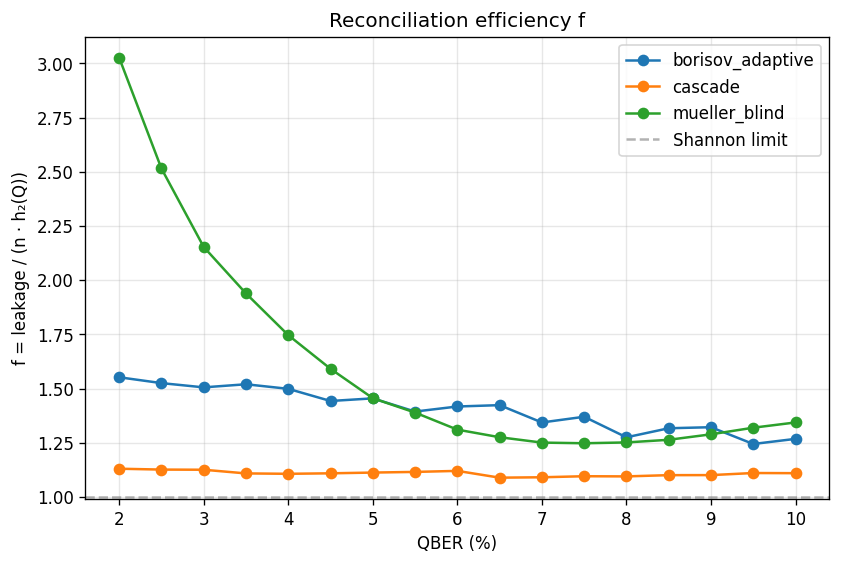

### N=1024: `f_eff_with_cluster`

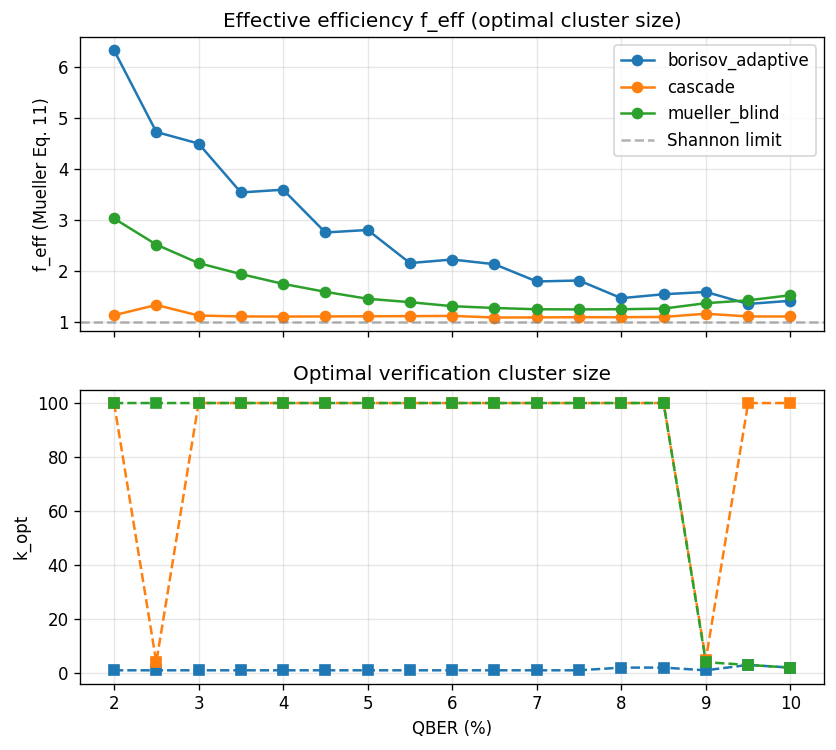

### N=1024: `messages_per_bit`

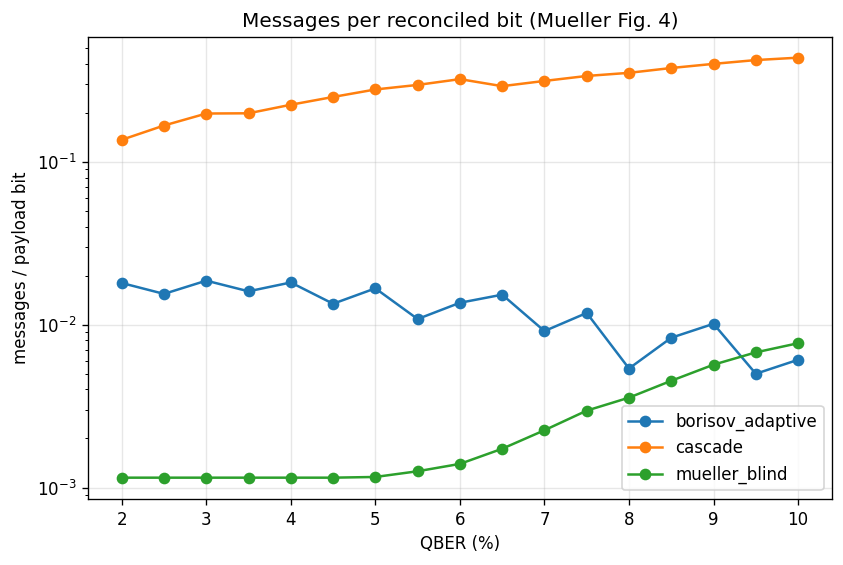

### N=1024: `fer`

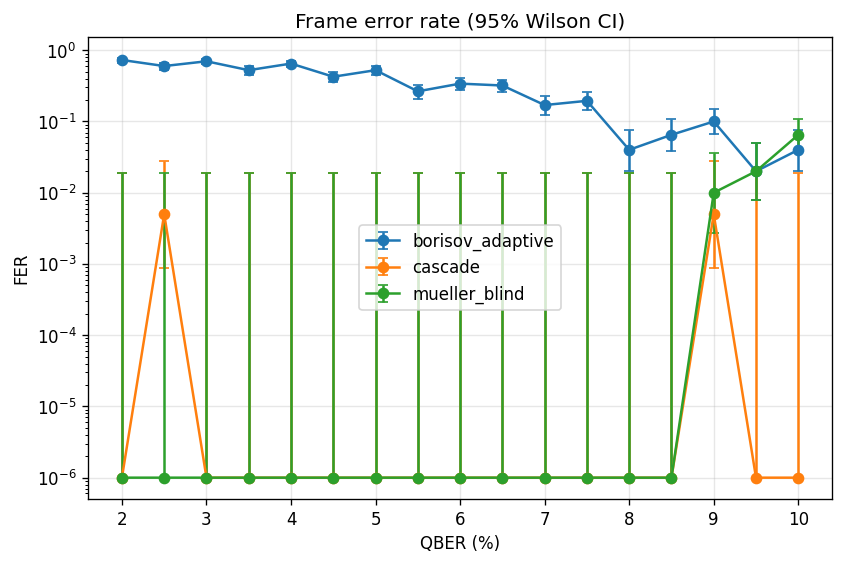

### N=1024: `wall_clock`

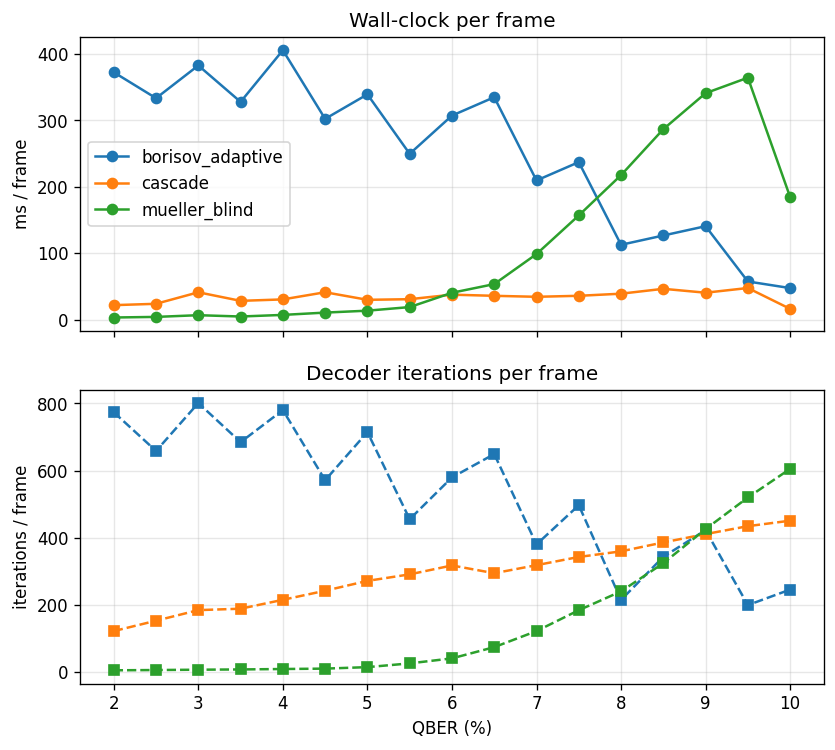

### N=1024: `secret_key_rate`

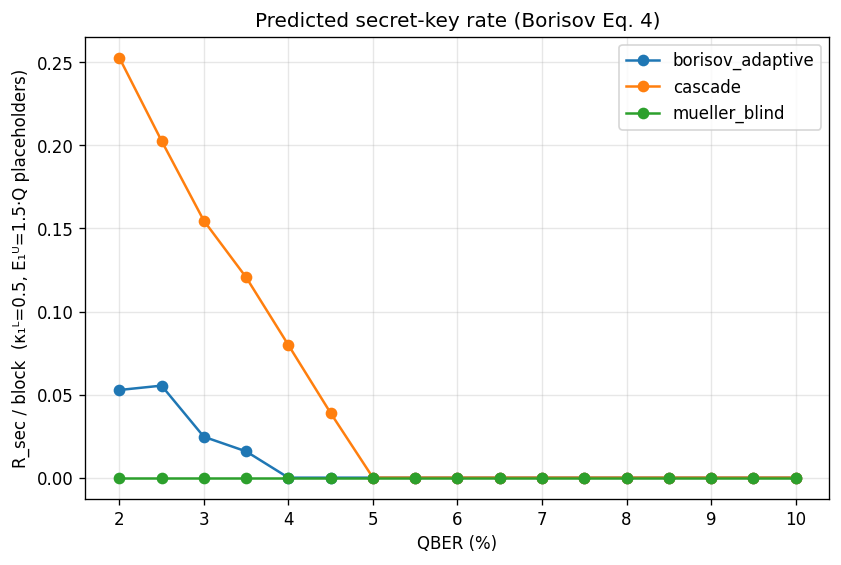

### N=1024: `mismatch`

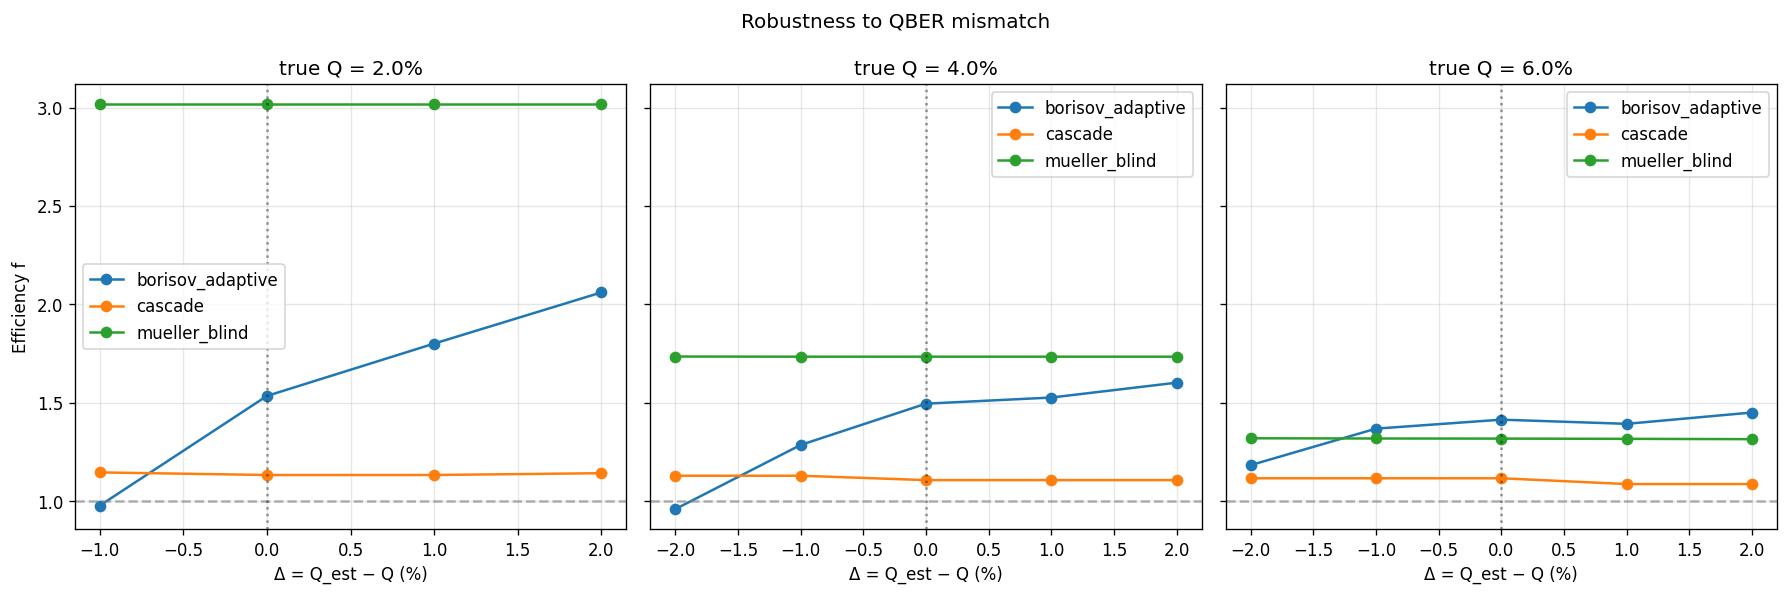

### N=1024: per-(alg, Q) summary

,alg,q,FER,f,f_eff,mean_messages,mean_wall_ms,R_sec_per_block
0,borisov_adaptive,0.020,0.730,1.5519,6.3282,15.675,372.5150,0.0528
1,borisov_adaptive,0.025,0.600,1.5249,4.7266,13.440,333.4784,0.0554
2,borisov_adaptive,0.030,0.700,1.5053,4.4990,16.205,382.7587,0.0246
3,borisov_adaptive,0.035,0.525,1.5196,3.5417,13.940,327.9089,0.0158
4,borisov_adaptive,0.040,0.650,1.4986,3.5951,15.795,405.7037,0.0000
5,borisov_adaptive,0.045,0.425,1.4424,2.7569,11.690,302.3768,0.0000
6,borisov_adaptive,0.050,0.525,1.4546,2.8060,14.535,339.2753,0.0000
7,borisov_adaptive,0.055,0.265,1.3937,2.1576,9.420,249.6974,0.0000
8,borisov_adaptive,0.060,0.340,1.4171,2.2273,11.855,307.2833,0.0000
9,borisov_adaptive,0.065,0.320,1.4233,2.1349,13.290,334.9699,0.0000



=== N=1024 done in 11.1m total ===

>>> Next: N=8192   ETA: ~7 min


# === N = 8192 ===   ETA: ~7 min

payload/frame= 6963
n=8192: code pool present, skipping generation

QBER sweep N=8192: 17 points on 16 workers...


Process SpawnPoolWorker-94:
Process SpawnPoolWorker-85:
Process SpawnPoolWorker-96:
Process SpawnPoolWorker-95:
Process SpawnPoolWorker-81:
Process SpawnPoolWorker-91:
Process SpawnPoolWorker-83:
Process SpawnPoolWorker-92:
Process SpawnPoolWorker-86:
Process SpawnPoolWorker-82:
Process SpawnPoolWorker-93:
Process SpawnPoolWorker-90:
Process SpawnPoolWorker-84:
Process SpawnPoolWorker-87:
Process SpawnPoolWorker-88:
Process SpawnPoolWorker-89:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/alex/miniconda3/envs/qkd/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/alex/miniconda3/envs/qkd/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/alex/miniconda3/envs/qkd/lib/python3.13/multiprocessing/pool.py", lin

KeyboardInterrupt: 

In [12]:
import multiprocessing as mp
import time
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from src.codes.storage import list_available
from src.harness import (
    make_borisov,
    make_cascade,
    make_mueller,
    make_slide_deck,
    per_qa_summary,
    run_mismatch_sweep,
)
from src.harness.parallel_worker import one_qber_point


def _needs_codes(target_n: int) -> bool:
    pool = list_available()
    return sum(1 for n, _ in pool if n == target_n) < 9


SUMMARY_COLS = ['alg', 'q', 'FER', 'f', 'f_eff',
                'mean_messages', 'mean_wall_ms', 'R_sec_per_block']

for idx, N in enumerate(N_VALUES):
    display(Markdown(
        f'# === N = {N} ===   ETA: {ETA_PER_N.get(N, "?")}'
    ))
    t_n0 = time.perf_counter()

    out_n = Path(OUT_DIR) / f'N{N}'
    plots_dir = out_n / 'plots'
    out_n.mkdir(parents=True, exist_ok=True)

    payload = N - round(ALPHA * N)
    print(f'payload/frame= {payload}')

    # (a) ensure code pool for this N
    if _needs_codes(N):
        print(f'[!] missing n={N} codes; generating '
              f'(this can take ~15 min at N=16384)...')
        rc = os.system(
            f'cd {REPO_DIR} && python -m src.tools.generate_codes '
            f'--frame-lengths {N}'
        )
        if rc != 0:
            raise RuntimeError(f'code generation failed for n={N} (exit {rc})')
    else:
        print(f'n={N}: code pool present, skipping generation')

    # (b) parallel QBER sweep
    n_workers = min(len(QBERS), os.cpu_count() or 2)
    work = [(q, payload, FRAMES_PER_Q, SEED, N, ALPHA, REPO_DIR, SKIP_BORISOV)
            for q in QBERS]
    print(f'\nQBER sweep N={N}: {len(work)} points on {n_workers} workers...')
    t0 = time.perf_counter()
    ctx = mp.get_context('spawn')
    parts = []
    with ctx.Pool(processes=n_workers) as pool:
        for i, df_part in enumerate(pool.imap_unordered(one_qber_point, work)):
            parts.append(df_part)
            q_done = df_part['q'].iloc[0]
            print(f'  [{i+1:>2}/{len(work)}] Q={q_done:.3f} done  '
                  f'({(time.perf_counter()-t0)/60:.1f}m elapsed)')
    df_q = pd.concat(parts, ignore_index=True)
    qber_path = out_n / 'qber_sweep.parquet'
    df_q.to_parquet(qber_path, index=False)
    qber_results[N] = df_q
    print(f'QBER sweep N={N} total: {(time.perf_counter()-t0)/60:.1f}m  '
          f'|  {len(df_q)} rows -> {qber_path}')

    # (c) mismatch sweep
    algorithms = [make_cascade(seed=SEED), make_mueller(n=N, seed=SEED)]
    if not SKIP_BORISOV:
        algorithms.append(make_borisov(n=N, alpha=ALPHA, seed=SEED))
    print(f'\nMismatch sweep N={N}: '
          f'3 trueQ x 5 deltas x {FRAMES_PER_Q} frames x {len(algorithms)} alg...')
    t0 = time.perf_counter()
    df_m = run_mismatch_sweep(
        algorithms,
        true_qbers=[0.02, 0.04, 0.06],
        deltas=[-0.02, -0.01, 0.0, 0.01, 0.02],
        n_frames_per_point=FRAMES_PER_Q,
        n_payload=payload,
        seed=SEED,
        progress_callback=lambda m: print(f'  {m}'),
    )
    mismatch_path = out_n / 'mismatch_sweep.parquet'
    df_m.to_parquet(mismatch_path, index=False)
    mismatch_results[N] = df_m
    print(f'Mismatch sweep N={N} total: {(time.perf_counter()-t0)/60:.1f}m  '
          f'|  {len(df_m)} rows -> {mismatch_path}')

    # (d) plots inline
    paths = make_slide_deck(df_q, df_m, n_payload=payload, out_dir=plots_dir)
    print(f'\nrendered {len(paths)} plots -> {plots_dir}/')
    for name, p in paths.items():
        display(Markdown(f'### N={N}: `{name}`'))
        display(Image(str(p)))

    # (e) summary table
    summary = per_qa_summary(df_q, n_payload=payload)
    display(Markdown(f'### N={N}: per-(alg, Q) summary'))
    display(summary[SUMMARY_COLS].round(4))

    total_min = (time.perf_counter() - t_n0) / 60
    print(f'\n=== N={N} done in {total_min:.1f}m total ===')

    # (f) announce next N
    if idx + 1 < len(N_VALUES):
        next_n = N_VALUES[idx + 1]
        print(f'\n>>> Next: N={next_n}   ETA: {ETA_PER_N.get(next_n, "?")}')

print('\nAll N values processed.')
print(f'qber_results keys     : {sorted(qber_results)}')
print(f'mismatch_results keys : {sorted(mismatch_results)}')

## Cell 4 — Cross-`N` comparison plot + global zip

Joins the per-`N` QBER sweeps into a single `f` vs `Q` view (one curve
per `(alg, N)` pair), then bundles every `local_results/N{N}/` subdir
into `local_results/qkd_sweep_all_N.zip`.

In [ ]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# --- (a) cross-N comparison plot: f vs Q ---
rows = []
for n_val, df in qber_results.items():
    payload_n = n_val - round(ALPHA * n_val)
    s = per_qa_summary(df, n_payload=payload_n).copy()
    s['N'] = n_val
    rows.append(s)
combined = pd.concat(rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=combined,
    x='q', y='f',
    hue='alg', style='N',
    markers=True, dashes=True,
    ax=ax,
)
ax.set_xlabel('QBER')
ax.set_ylabel(r'Reconciliation efficiency $f = \mathrm{leak} / (n\,h(Q))$')
ax.set_title('Reconciliation efficiency vs QBER — across N')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
fig.tight_layout()

compare_path = Path(OUT_DIR) / 'plots_compare_f_vs_q.png'
fig.savefig(compare_path, dpi=150)
plt.show()
print(f'comparison plot saved -> {compare_path}')

# --- (b) global zip with one folder per N ---
stage = Path(OUT_DIR) / 'staging_all'
shutil.rmtree(stage, ignore_errors=True)
stage.mkdir(parents=True)
for n_val in sorted(qber_results):
    src_dir = Path(OUT_DIR) / f'N{n_val}'
    if src_dir.exists():
        shutil.copytree(src_dir, stage / f'N{n_val}')

zip_base = Path(OUT_DIR) / 'qkd_sweep_all_N'
# shutil.make_archive appends the '.zip' suffix.
zip_path = shutil.make_archive(str(zip_base), 'zip', str(stage))
size_mb = os.path.getsize(zip_path) / 1024 / 1024
print(f'Created {zip_path} ({size_mb:.1f} MB)')
shutil.rmtree(stage, ignore_errors=True)